# Gothic NLDAS radiation comparison

This notebook compares Gothic surface radiation observations with the local point-only NLDAS evaluation table. It intentionally removes the old cloud-mask, GOES RGB, and k_t ratio workflow.

Current local inputs support the 2022 shortwave comparison. The LW section below checks what is available locally and reports why a LW-to-obs plot cannot be made from the present Gothic observation files.


In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/glade/derecho/scratch/cdalden/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

CWD = Path.cwd()
ROOT = CWD.parent if CWD.name == "analysis" and (CWD / "17_nldas_sandbox.ipynb").exists() else CWD
ANALYSIS_DIR = ROOT / "analysis"
OUT_DIR = ANALYSIS_DIR / "output_17_nldas_point_eval"

GOTHIC_LAT = 38.96
GOTHIC_LON = -106.99
NLDAS2_DIR = Path("/glade/u/home/cdalden/scratch/nldas")
NLDAS3_DIR = Path("/glade/derecho/scratch/cdalden/tmp/nldas3_sw")
NLDAS2_LW_DIR = Path("/glade/derecho/scratch/cdalden/tmp/nldas2_lw")
NLDAS3_LW_DIR = Path("/glade/derecho/scratch/cdalden/tmp/nldas3_lw")
GOTHIC_OBS_DIR = Path("/glade/u/home/cdalden/scratch/surface_obs/colorado/gucsebsM1.b1")
SOS_OBS_PATH = Path("/glade/u/home/cdalden/scratch/surface_obs/colorado/sos_full_dataset_30min.nc")
GUC_LW_DIR = Path("/glade/u/home/cdalden/scratch/surface_obs/colorado/guc_LW")

CSV_PATH = OUT_DIR / "gothic_nldas_point_sw_20210901_20230630_h14-23-0.csv"
RAD_CACHE_PATH = OUT_DIR / "gothic_nldas3_sw_lw_obs_cache_20210901_20230630.csv"
HOURS_LABEL = "14-23,0 UTC"


In [2]:
def require_file(path: Path, build_hint: str = "") -> Path:
    if not path.exists():
        message = f"Missing required file: {path}"
        if build_hint:
            message += "\nBuild it with:\n" + build_hint
        raise FileNotFoundError(message)
    return path


def load_sw_comparison(path: Path) -> pd.DataFrame:
    build_hint = (
        "python analysis/build_nldas_point_eval.py "
        "--start 2022-01-01 --end 2022-12-31 --hours 14-23,0"
    )
    require_file(path, build_hint)
    df = pd.read_csv(path, parse_dates=["time_utc"])
    keep = ["time_utc", "nldas2", "nldas3", "gothic_obs_sw"]
    missing = [col for col in keep if col not in df.columns]
    if missing:
        raise ValueError(f"{path} is missing expected columns: {missing}")
    df = df[keep].copy()
    for col in ["nldas2", "nldas3", "gothic_obs_sw"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


sw = load_sw_comparison(CSV_PATH)
print(f"Loaded {len(sw):,} requested Gothic comparison hours from {CSV_PATH}")
print(f"Time span: {sw.time_utc.min()} to {sw.time_utc.max()} ({HOURS_LABEL})")
print(sw.notna().sum().rename("non_null").to_frame().T)


Loaded 4,015 requested Gothic comparison hours from /glade/u/home/cdalden/goes_work/analysis/output_17_nldas_point_eval/gothic_nldas_point_sw_20220101_20221231_h14-23-0.csv
Time span: 2022-01-01 14:00:00 to 2023-01-01 00:00:00 (14-23,0 UTC)
          time_utc  nldas2  nldas3  gothic_obs_sw
non_null      4015    4014    4015           4015


In [3]:
def model_metrics(df: pd.DataFrame, model_col: str, obs_col: str = "gothic_obs_sw") -> dict:
    valid = df[[model_col, obs_col]].dropna()
    err = valid[model_col] - valid[obs_col]
    return {
        "source": model_col,
        "n": len(valid),
        "bias_wm2": err.mean(),
        "mae_wm2": err.abs().mean(),
        "rmse_wm2": np.sqrt(np.mean(err**2)),
        "corr": valid[model_col].corr(valid[obs_col]),
    }


metrics = pd.DataFrame([model_metrics(sw, "nldas2"), model_metrics(sw, "nldas3")])
metrics.round({"bias_wm2": 2, "mae_wm2": 2, "rmse_wm2": 2, "corr": 3})


,source,n,bias_wm2,mae_wm2,rmse_wm2,corr
0,nldas2,4014,149.34,158.97,213.09,0.853
1,nldas3,4015,27.26,106.28,133.26,0.884


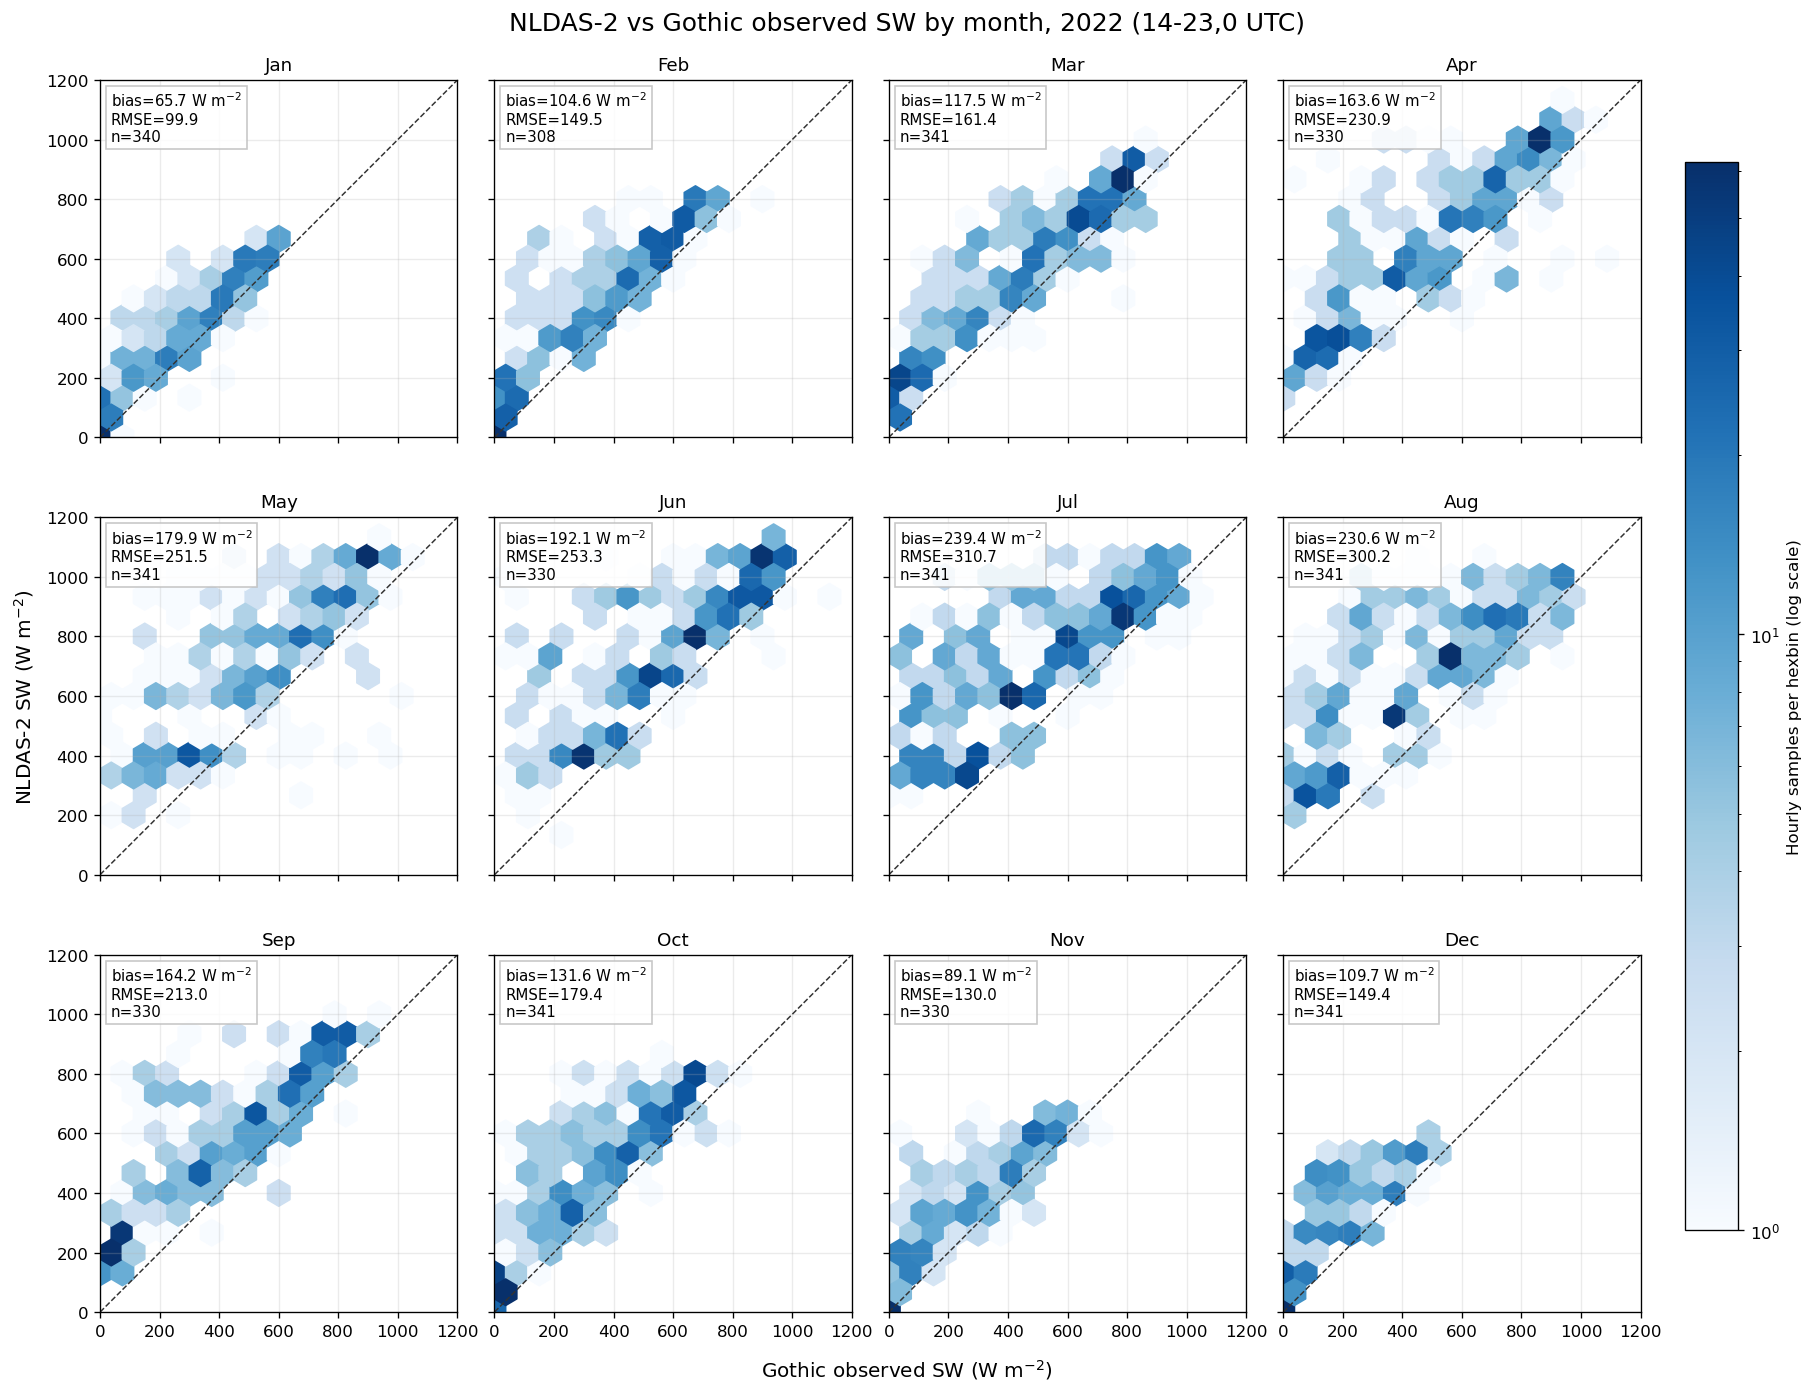

In [4]:
MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


def plot_monthly_hexbin(df: pd.DataFrame, model_col: str, label: str, cmap: str):
    plot_df = df[["time_utc", model_col, "gothic_obs_sw"]].dropna().copy()
    plot_df["month"] = plot_df["time_utc"].dt.month
    max_sw = np.nanmax(plot_df[[model_col, "gothic_obs_sw"]].to_numpy())
    limit = float(np.ceil(max_sw / 100.0) * 100.0)

    fig, axes = plt.subplots(3, 4, figsize=(15, 11.5), sharex=True, sharey=True, constrained_layout=True)
    axes = axes.ravel()
    last_hex = None

    for month, ax in enumerate(axes, start=1):
        month_df = plot_df[plot_df["month"] == month]
        if month_df.empty:
            ax.set_axis_off()
            continue

        x = month_df["gothic_obs_sw"]
        y = month_df[model_col]
        err = y - x
        last_hex = ax.hexbin(
            x,
            y,
            gridsize=16,
            extent=(0, limit, 0, limit),
            mincnt=1,
            cmap=cmap,
            bins="log",
        )
        ax.plot([0, limit], [0, limit], color="0.2", lw=0.9, ls="--")
        ax.set_title(MONTH_NAMES[month - 1], fontsize=11)
        ax.text(
            0.03,
            0.97,
            f"bias={err.mean():.1f} W m$^{{-2}}$\nRMSE={np.sqrt(np.mean(err**2)):.1f}\nn={len(month_df)}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox={"facecolor": "white", "edgecolor": "0.75", "alpha": 0.85, "pad": 3},
        )
        ax.set_xlim(0, limit)
        ax.set_ylim(0, limit)
        ax.set_aspect("equal", adjustable="box")

    fig.supxlabel("Gothic observed SW (W m$^{-2}$)")
    fig.supylabel(f"{label} SW (W m$^{{-2}}$)")
    fig.suptitle(f"{label} vs Gothic observed SW by month, 2022 ({HOURS_LABEL})", fontsize=15)
    if last_hex is not None:
        cbar = fig.colorbar(last_hex, ax=axes.tolist(), shrink=0.82, pad=0.015)
        cbar.set_label("Hourly samples per hexbin (log scale)")
    return fig


nldas2_hex_fig = plot_monthly_hexbin(sw, "nldas2", "NLDAS-2", "Blues")
# nldas2_hex_fig


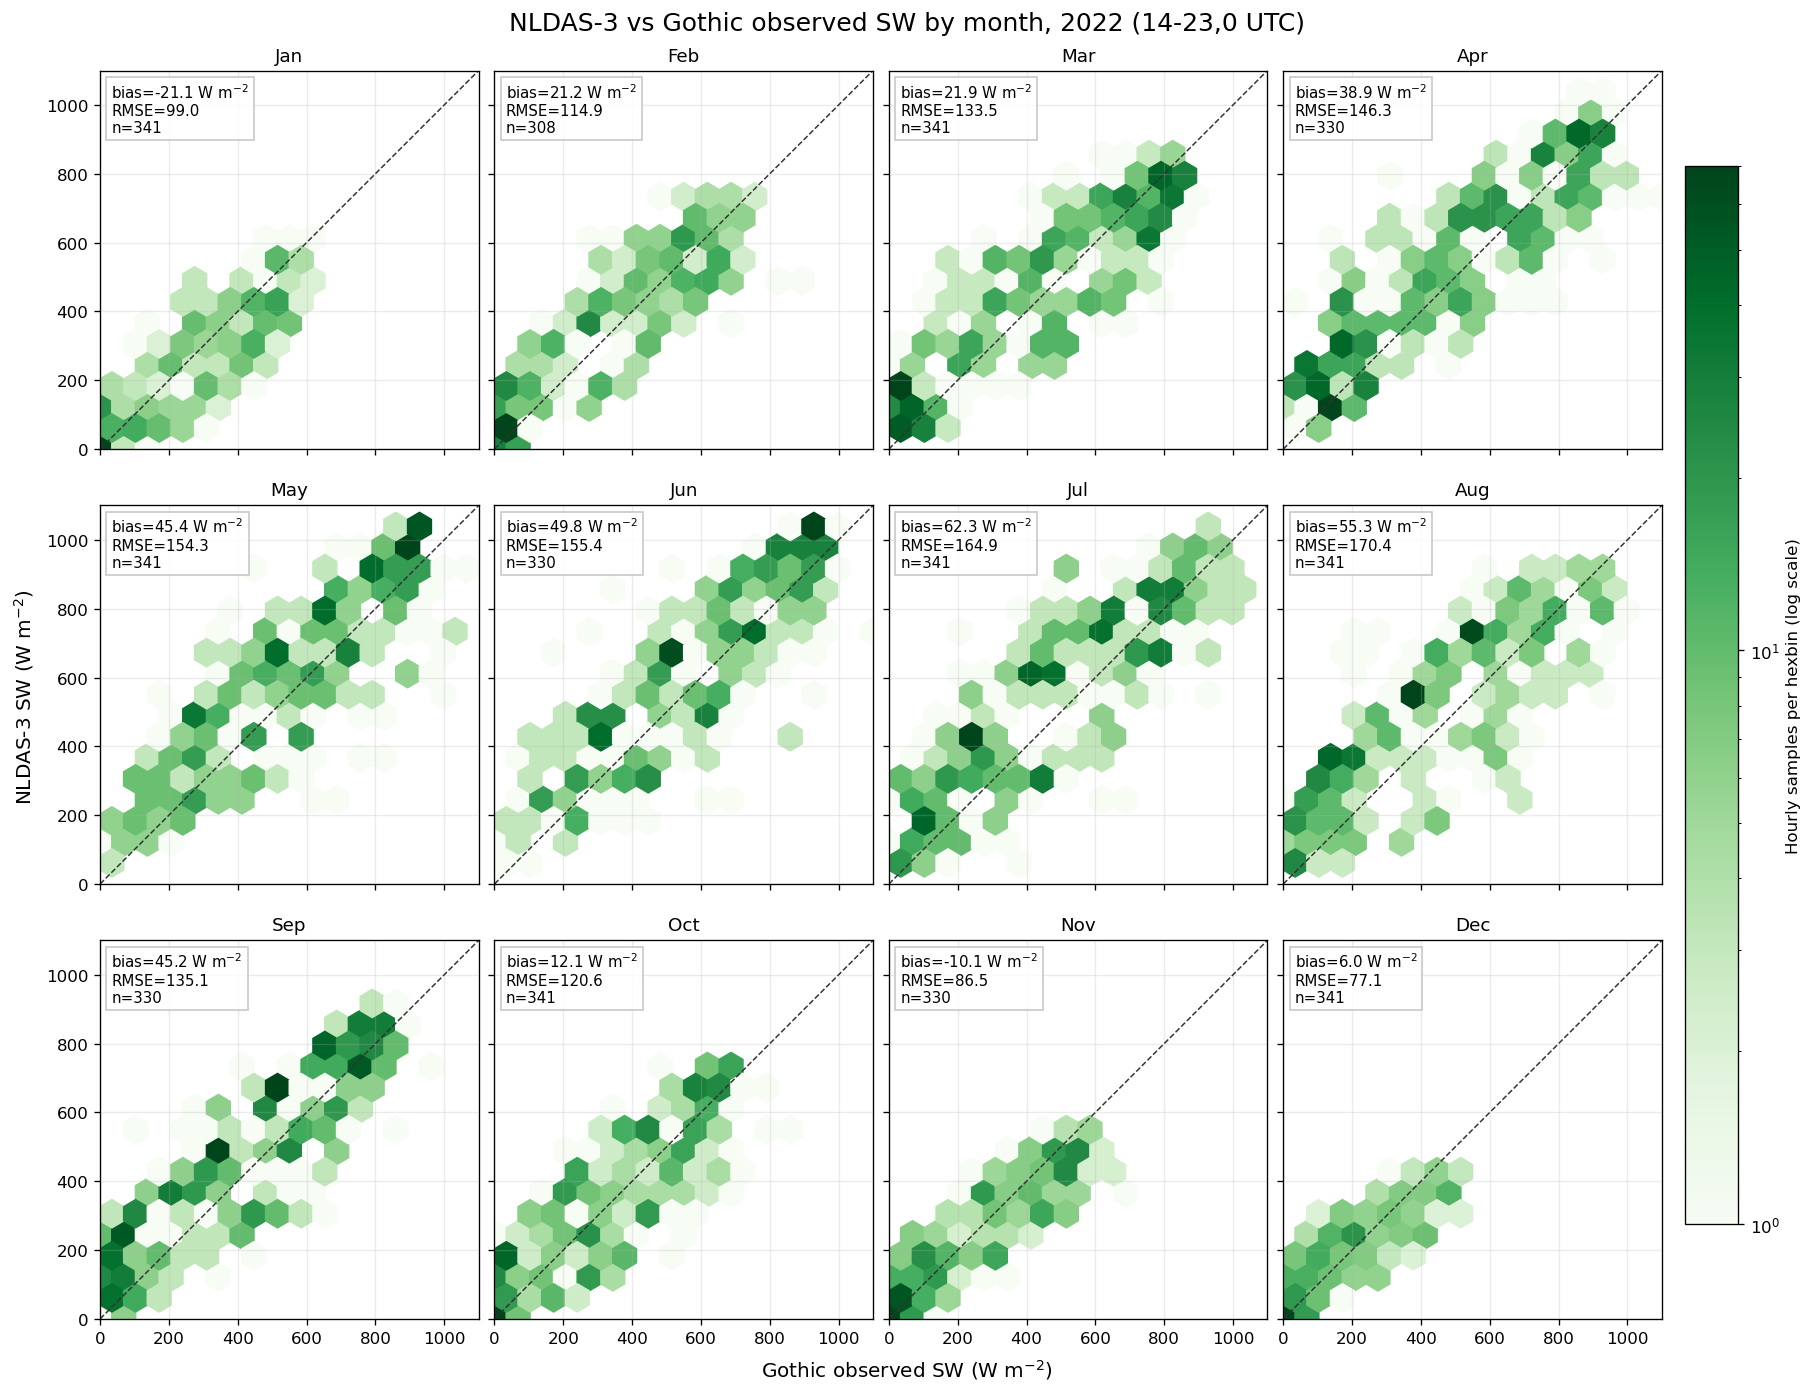

In [5]:
nldas3_hex_fig = plot_monthly_hexbin(sw, "nldas3", "NLDAS-3", "Greens")
# nldas3_hex_fig


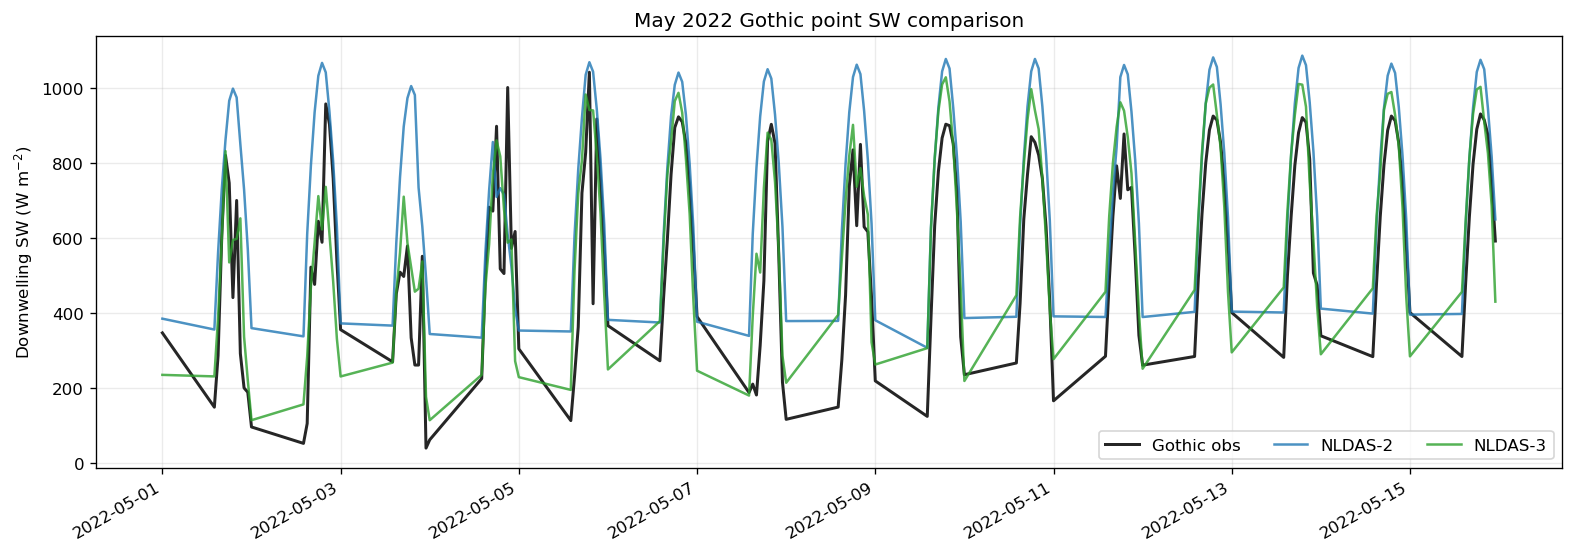

In [6]:
plot_start = "2022-05-01"
plot_end = "2022-05-15 23:59"
subset = sw[(sw.time_utc >= plot_start) & (sw.time_utc <= plot_end)].copy()

may_fig, ax = plt.subplots(figsize=(13, 4.5), constrained_layout=True)
ax.plot(subset.time_utc, subset.gothic_obs_sw, label="Gothic obs", color="0.15", lw=1.8)
ax.plot(subset.time_utc, subset.nldas2, label="NLDAS-2", color="tab:blue", alpha=0.8)
ax.plot(subset.time_utc, subset.nldas3, label="NLDAS-3", color="tab:green", alpha=0.8)
ax.set_ylabel("Downwelling SW (W m$^{-2}$)")
ax.set_title("May 2022 Gothic point SW comparison")
ax.legend(ncol=3)
may_fig.autofmt_xdate()
# may_fig


## NLDAS3 LW vs Gothic LW Obs

This plot uses the local Gothic/GUC qcrad longwave files (`gucqcrad1longM1.c2`) from `/glade/u/home/cdalden/scratch/surface_obs/colorado/guc_LW`. The LW comparison window is all hourly timesteps from `2021-09-01 00:00` through `2023-06-30 23:00`.


In [7]:
LW_START = "2021-09-01"
LW_END = "2023-06-30"
LW_HOURS = "0-23"


def load_radiation_cache(path: Path = RAD_CACHE_PATH) -> pd.DataFrame:
    build_hint = "python analysis/build_nldas3_rad_obs_cache.py"
    require_file(path, build_hint)
    cache = pd.read_csv(path, parse_dates=["time_utc"])
    expected = ["time_utc", "nldas2_sw", "nldas3_sw", "gothic_obs_sw", "nldas3_lw", "guc_obs_lw"]
    missing = [col for col in expected if col not in cache.columns]
    if missing:
        raise ValueError(f"{path} is missing expected columns: {missing}")
    for col in expected[1:]:
        cache[col] = pd.to_numeric(cache[col], errors="coerce")
    return cache


rad_cache = load_radiation_cache()
lw_compare = rad_cache[["time_utc", "nldas3_lw", "guc_obs_lw"]].copy()
print(f"Loaded radiation cache: {RAD_CACHE_PATH}")
print(f"Cache rows: {len(rad_cache):,}")
print(f"LW window: {lw_compare.time_utc.min()} to {lw_compare.time_utc.max()} ({LW_HOURS} UTC)")
print(f"NLDAS3 LW rows: {lw_compare['nldas3_lw'].notna().sum():,}")
print(f"GUC LW matched rows: {lw_compare['guc_obs_lw'].notna().sum():,}")
rad_cache.notna().sum().rename("non_null").to_frame().T


Loaded radiation cache: /glade/u/home/cdalden/goes_work/analysis/output_17_nldas_point_eval/gothic_nldas3_sw_lw_obs_cache_20210901_20230630.csv
Cache rows: 16,032
LW window: 2021-09-01 00:00:00 to 2023-06-30 23:00:00 (0-23 UTC)
NLDAS3 LW rows: 16,032
GUC LW matched rows: 15,647


,time_utc,nldas2_sw,nldas3_sw,gothic_obs_sw,nldas3_lw,guc_obs_lw
non_null,16032,4014,4015,4015,16032,15647


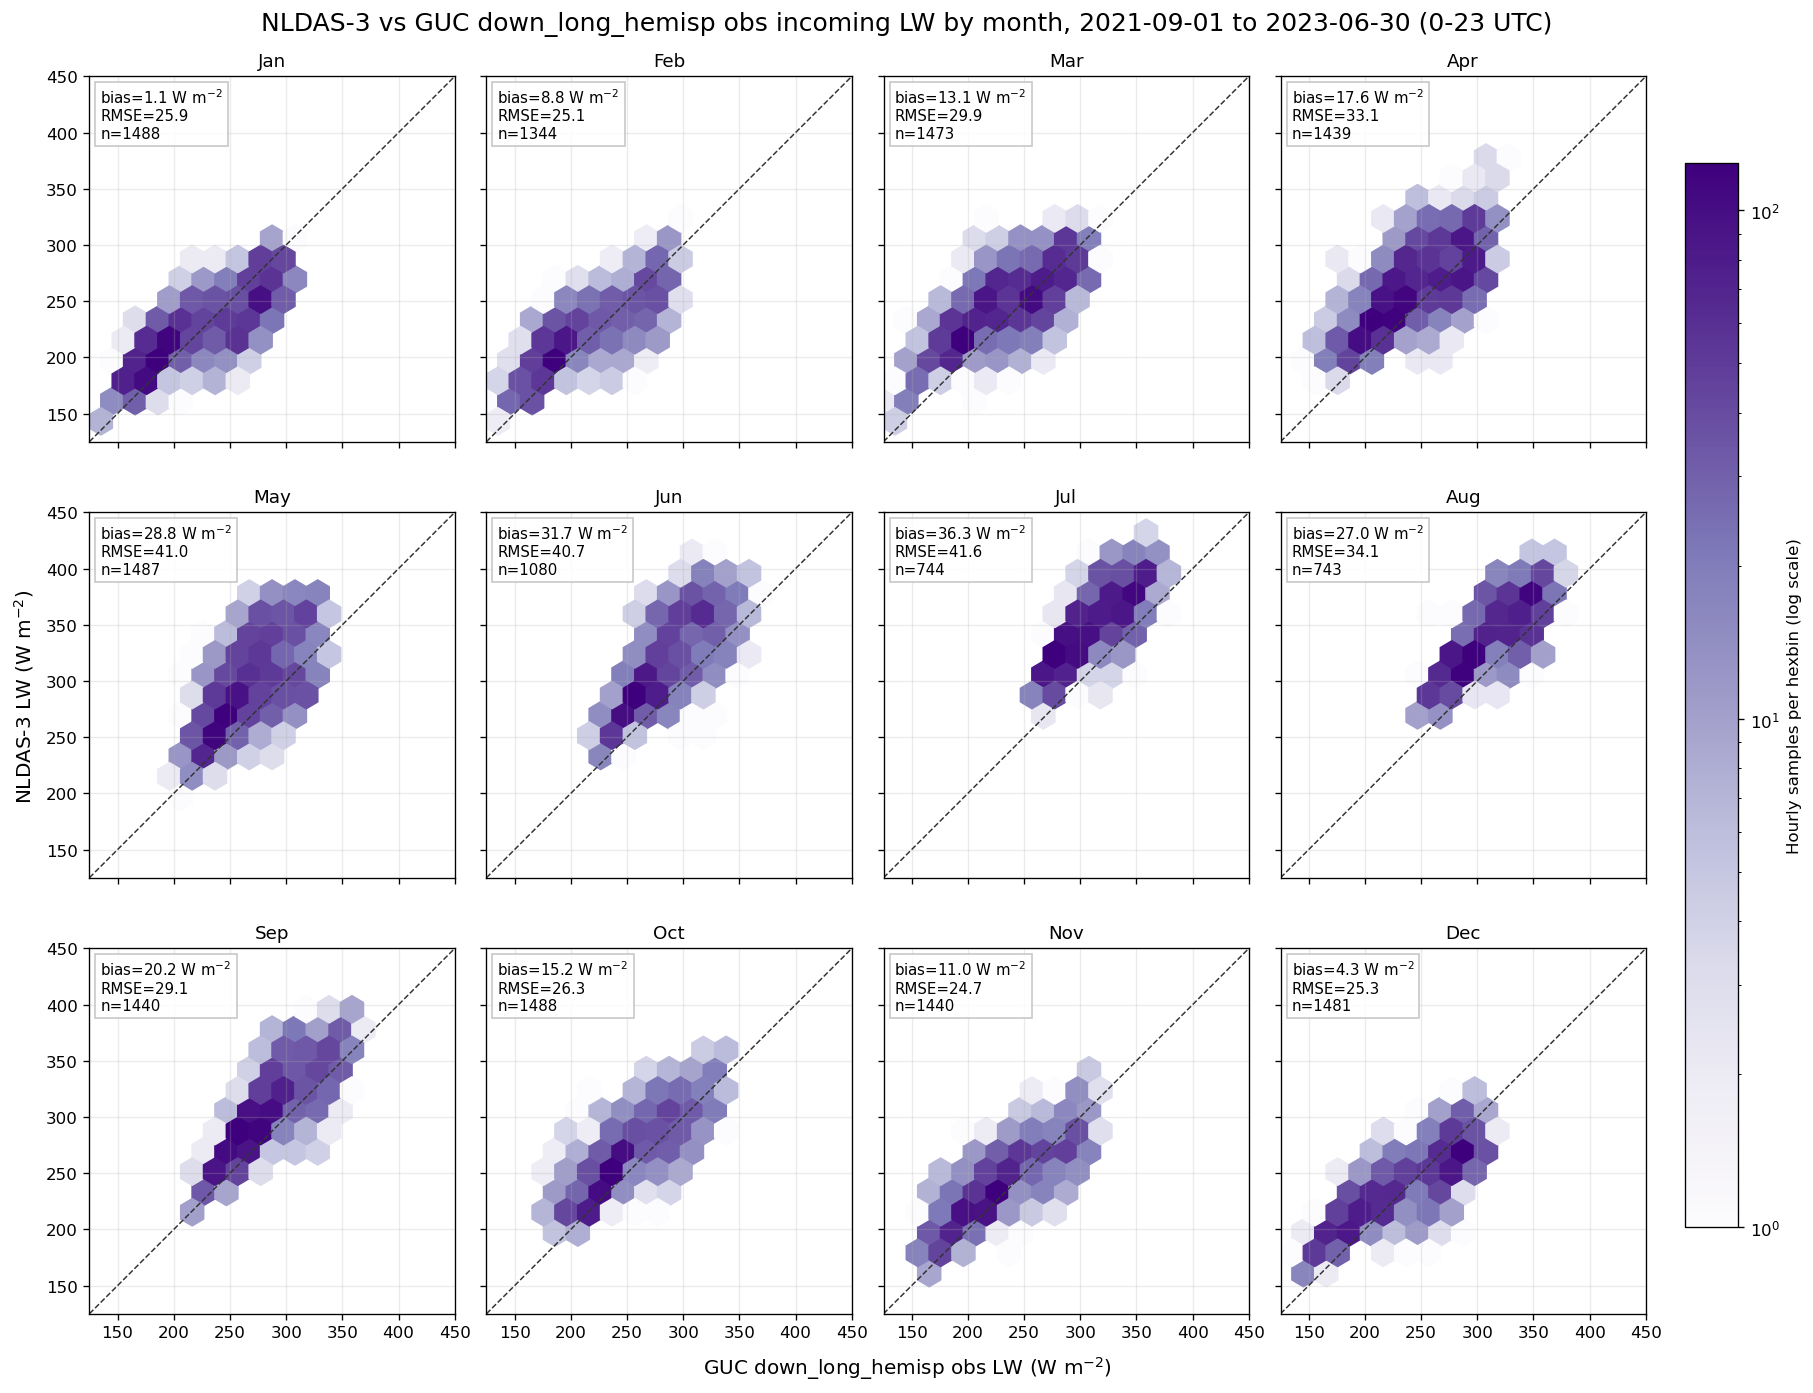

In [8]:
def plot_monthly_hexbin_lw(df: pd.DataFrame, model_col: str, obs_col: str, model_label: str, obs_label: str, cmap: str):
    plot_df = df[["time_utc", model_col, obs_col]].dropna().copy()
    plot_df["month"] = plot_df["time_utc"].dt.month
    if plot_df.empty:
        raise ValueError("No overlapping NLDAS3 LW and observation rows to plot")
    max_flux = np.nanmax(plot_df[[model_col, obs_col]].to_numpy())
    min_flux = np.nanmin(plot_df[[model_col, obs_col]].to_numpy())
    lower = float(np.floor(min_flux / 25.0) * 25.0)
    upper = float(np.ceil(max_flux / 25.0) * 25.0)

    fig, axes = plt.subplots(3, 4, figsize=(15, 11.5), sharex=True, sharey=True, constrained_layout=True)
    axes = axes.ravel()
    last_hex = None

    for month, ax in enumerate(axes, start=1):
        month_df = plot_df[plot_df["month"] == month]
        if month_df.empty:
            ax.set_axis_off()
            ax.set_title(MONTH_NAMES[month - 1], fontsize=11)
            continue

        x = month_df[obs_col]
        y = month_df[model_col]
        err = y - x
        last_hex = ax.hexbin(
            x,
            y,
            gridsize=16,
            extent=(lower, upper, lower, upper),
            mincnt=1,
            cmap=cmap,
            bins="log",
        )
        ax.plot([lower, upper], [lower, upper], color="0.2", lw=0.9, ls="--")
        ax.set_title(MONTH_NAMES[month - 1], fontsize=11)
        ax.text(
            0.03,
            0.97,
            f"bias={err.mean():.1f} W m$^{{-2}}$\nRMSE={np.sqrt(np.mean(err**2)):.1f}\nn={len(month_df)}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox={"facecolor": "white", "edgecolor": "0.75", "alpha": 0.85, "pad": 3},
        )
        ax.set_xlim(lower, upper)
        ax.set_ylim(lower, upper)
        ax.set_aspect("equal", adjustable="box")

    fig.supxlabel(f"{obs_label} LW (W m$^{{-2}}$)")
    fig.supylabel(f"{model_label} LW (W m$^{{-2}}$)")
    fig.suptitle(f"{model_label} vs {obs_label} incoming LW by month, {LW_START} to {LW_END} ({LW_HOURS} UTC)", fontsize=15)
    if last_hex is not None:
        cbar = fig.colorbar(last_hex, ax=axes.tolist(), shrink=0.82, pad=0.015)
        cbar.set_label("Hourly samples per hexbin (log scale)")
    return fig


nldas3_lw_hex_fig = plot_monthly_hexbin_lw(lw_compare, "nldas3_lw", "guc_obs_lw", "NLDAS-3", "GUC down_long_hemisp obs", "Purples")
# nldas3_lw_hex_fig


## Local LW availability

The next cell inspects representative local files for SW/LW variables. This keeps the notebook honest: it only plots LW when the required model and Gothic observation variables are present locally.


In [9]:
SW_CANDIDATES = ("SWdown", "SWDOWN", "DSWRF", "down_short_hemisp", "downwelling_shortwave_platform")
LW_CANDIDATES = ("LWdown", "LWDOWN", "DLWRF", "down_long_hemisp", "downwelling_longwave_platform")


def find_nldas2_sw_sample():
    clean = sorted(NLDAS2_DIR.glob("NLDAS_FOR*.nc*"))
    if clean:
        return clean[0]
    all_matches = sorted(NLDAS2_DIR.glob("*A2022*.nc*"))
    return all_matches[0] if all_matches else None


def find_nldas2_lw_sample():
    matches = sorted(NLDAS2_LW_DIR.glob("*LWdown*.nc*"))
    return matches[0] if matches else None


def find_nldas3_sw_sample():
    matches = sorted(NLDAS3_DIR.glob("nldas3_sw_2022*.nc"))
    return matches[0] if matches else None


def find_nldas3_lw_sample():
    matches = sorted(NLDAS3_LW_DIR.glob("nldas3_lwdown_2022*.nc"))
    return matches[0] if matches else None


def find_obs_sample():
    matches = sorted(GOTHIC_OBS_DIR.glob("gucsebsM1.b1.2022*.cdf"))
    return matches[0] if matches else None


def find_guc_lw_sample():
    matches = sorted(GUC_LW_DIR.glob("gucqcrad1longM1.c2.*.cdf"))
    return matches[0] if matches else None


def inspect_dataset(label, path):
    if path is None:
        return {
            "source": label,
            "path": "missing",
            "has_sw": False,
            "sw_vars": "",
            "has_lw": False,
            "lw_vars": "",
            "dims": "",
        }
    with xr.open_dataset(path) as ds:
        names = set(ds.variables)
        sw_vars = [name for name in SW_CANDIDATES if name in names]
        lw_vars = [name for name in LW_CANDIDATES if name in names]
        dims = dict(ds.sizes)
    return {
        "source": label,
        "path": str(path),
        "has_sw": bool(sw_vars),
        "sw_vars": ", ".join(sw_vars),
        "has_lw": bool(lw_vars),
        "lw_vars": ", ".join(lw_vars),
        "dims": dims,
    }


availability = pd.DataFrame([
    inspect_dataset("NLDAS-2 SW cache", find_nldas2_sw_sample()),
    inspect_dataset("NLDAS-2 LW cache", find_nldas2_lw_sample()),
    inspect_dataset("NLDAS-3 SW cache", find_nldas3_sw_sample()),
    inspect_dataset("NLDAS-3 LW cache", find_nldas3_lw_sample()),
    inspect_dataset("Gothic SW obs", find_obs_sample()),
    inspect_dataset("GUC LW obs", find_guc_lw_sample()),
])
availability


,source,path,has_sw,sw_vars,has_lw,lw_vars,dims
0,NLDAS-2 SW cache,/glade/u/home/cdalden/scratch/nldas/NLDAS_FORB...,True,SWdown,False,,"{'time': 1, 'bnds': 2, 'lat': 3, 'lon': 3}"
1,NLDAS-2 LW cache,missing,False,,False,,
2,NLDAS-3 SW cache,/glade/derecho/scratch/cdalden/tmp/nldas3_sw/n...,True,SWdown,False,,"{'lat': 1, 'lon': 1}"
3,NLDAS-3 LW cache,/glade/derecho/scratch/cdalden/tmp/nldas3_lw/n...,False,,True,LWdown,"{'lat': 1, 'lon': 1}"
4,Gothic SW obs,/glade/u/home/cdalden/scratch/surface_obs/colo...,True,down_short_hemisp,False,,{'time': 48}
5,GUC LW obs,/glade/u/home/cdalden/scratch/surface_obs/colo...,True,down_short_hemisp,True,down_long_hemisp,{'time': 1440}


In [10]:
lw_ready = availability.set_index("source")["has_lw"].to_dict()
required_sources = ["NLDAS-2 LW cache", "NLDAS-3 LW cache", "GUC LW obs"]
missing_lw = [source for source in required_sources if not lw_ready.get(source, False)]

if missing_lw:
    print("LW vs Gothic obs plot is not produced because LW is missing from:")
    for source in missing_lw:
        print(f"- {source}")
    print("\nNLDAS-3 LWdown is now cached at /glade/derecho/scratch/cdalden/tmp/nldas3_lw.")
    print("NLDAS-2 LWdown still requires Earthdata-authenticated GES DISC access.")
    print("GUC LW obs are read from /glade/u/home/cdalden/scratch/surface_obs/colorado/guc_LW.")
else:
    print("All required LW sources are present; add/read LW columns here before plotting.")


LW vs Gothic obs plot is not produced because LW is missing from:
- NLDAS-2 LW cache

NLDAS-3 LWdown is now cached at /glade/derecho/scratch/cdalden/tmp/nldas3_lw.
NLDAS-2 LWdown still requires Earthdata-authenticated GES DISC access.
GUC LW obs are read from /glade/u/home/cdalden/scratch/surface_obs/colorado/guc_LW.


## NLDAS3 SW and LW All-Timestep Comparison

This final figure uses the cached comparison CSV: SW NLDAS3 vs Gothic obs on the left, and LW NLDAS3 vs GUC qcrad longwave obs on the right.


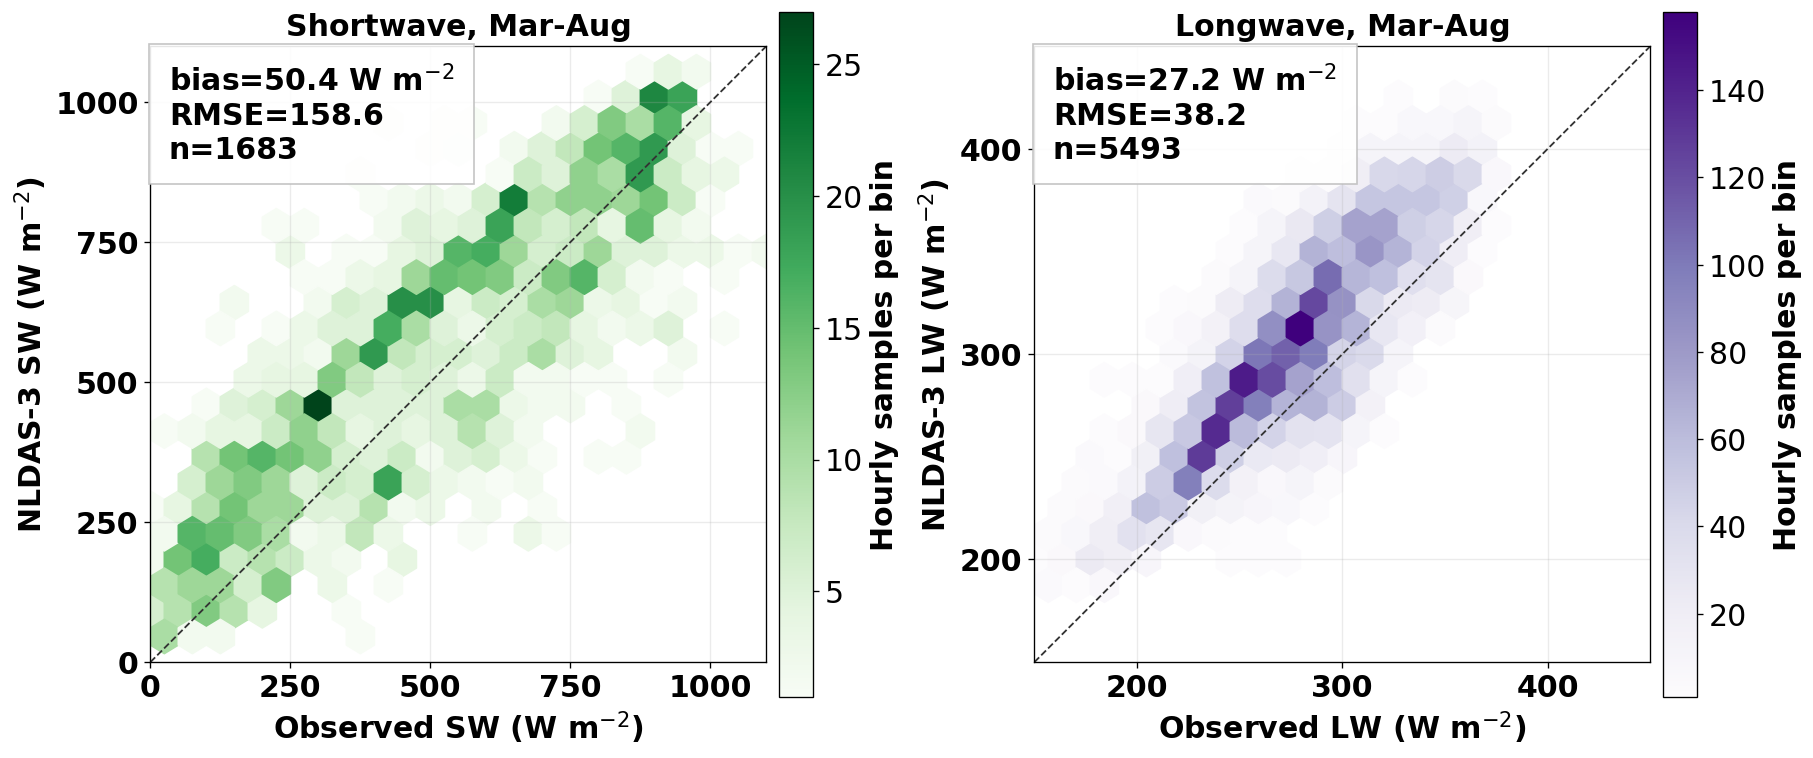

In [16]:
def plot_all_timestep_hex(ax, df: pd.DataFrame, obs_col: str, model_col: str, title: str, xlabel: str, ylabel: str, cmap: str):
    valid = df[[obs_col, model_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if valid.empty:
        ax.set_axis_off()
        ax.set_title(f"{title}: no matched data")
        return None

    err = valid[model_col] - valid[obs_col]
    min_flux = float(np.nanmin(valid[[obs_col, model_col]].to_numpy()))
    max_flux = float(np.nanmax(valid[[obs_col, model_col]].to_numpy()))
    lower = float(np.floor(min_flux / 50.0) * 50.0)
    upper = float(np.ceil(max_flux / 50.0) * 50.0)
    if lower == upper:
        lower -= 1.0
        upper += 1.0

    hb = ax.hexbin(
        valid[obs_col],
        valid[model_col],
        gridsize=22,
        extent=(lower, upper, lower, upper),
        mincnt=1,
        cmap=cmap,
    )
    ax.plot([lower, upper], [lower, upper], color="0.2", lw=1.1, ls="--")
    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)
    ax.set_aspect("equal", adjustable="box")
    ax.locator_params(axis="both", nbins=5)
    ax.set_title(title, fontsize=18, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=18, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=18, fontweight="bold")
    ax.text(
        0.03,
        0.97,
        f"bias={err.mean():.1f} W m$^{{-2}}$\nRMSE={np.sqrt(np.mean(err**2)):.1f}\nn={len(valid)}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=18,
        fontweight="bold",
        bbox={"facecolor": "white", "edgecolor": "0.75", "alpha": 0.9, "pad": 12},
    )
    return hb


APRIL_AUGUST_MONTHS = [4, 5, 6, 7, 8]
rad_cache_apr_aug = rad_cache[rad_cache["time_utc"].dt.month.isin(APRIL_AUGUST_MONTHS)].copy()
lw_compare_apr_aug = lw_compare[lw_compare["time_utc"].dt.month.isin(APRIL_AUGUST_MONTHS)].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6.8), constrained_layout=True)

sw_hb = plot_all_timestep_hex(
    axes[0],
    rad_cache_apr_aug,
    obs_col="gothic_obs_sw",
    model_col="nldas3_sw",
    title="Shortwave, Apr-Aug",
    xlabel="Observed SW (W m$^{-2}$)",
    ylabel="NLDAS-3 SW (W m$^{-2}$)",
    cmap="Greens",
)

lw_hb = plot_all_timestep_hex(
    axes[1],
    lw_compare_apr_aug,
    obs_col="guc_obs_lw",
    model_col="nldas3_lw",
    title="Longwave, Apr-Aug",
    xlabel="Observed LW (W m$^{-2}$)",
    ylabel="NLDAS-3 LW (W m$^{-2}$)",
    cmap="Purples",
)

for ax, hb in zip(axes, [sw_hb, lw_hb]):
    if hb is not None:
        cbar = fig.colorbar(hb, ax=ax, shrink=0.85, pad=0.02)
        cbar.set_label("Hourly samples per bin", fontsize=18, fontweight="bold")
        cbar.ax.tick_params(labelsize=18)

# fig.suptitle("NLDAS-3 vs SAIL Surface Radiation Observations, March-August", fontsize=20, fontweight="bold")
for ax in axes:
    ax.tick_params(labelsize=18)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")